In [1]:
import pandas as pd

# Ground and Solargis

In [28]:
df_ground1 = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2020.csv')
df_ground2 = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2021.csv')

df_ground = pd.concat([df_ground1, df_ground2], ignore_index=True)
df_ground.dropna(inplace=True)
df_ground.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 699
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Day                     699 non-null    object 
 1   Temperature (C)         699 non-null    float64
 2   Temperature (SAT) (C)   699 non-null    float64
 3   Rain (mm)               699 non-null    float64
 4   GHI_1 (kWh/m2/day)      699 non-null    float64
 5   GHI_2 (kWh/m2/day)      699 non-null    float64
 6   GHI_SAT (kWh/m2/day)    699 non-null    float64
 7   GHI (1) vs (2) (%)      699 non-null    float64
 8   GHI (1) vs (SAT) (%)    699 non-null    float64
 9   DHI (1) (kWh/m2/day)    699 non-null    float64
 10  DHI (SAT) (kWh/m2/day)  699 non-null    float64
 11  DHI (1) vs (SAT) (%)    699 non-null    float64
dtypes: float64(11), object(1)
memory usage: 71.0+ KB


In [29]:
df_ground['Day'] = pd.to_datetime(df_ground['Day'])
df_ground.set_index('Day', inplace=True)
df_ground.sort_index(inplace=True)
df_ground.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 699 entries, 2020-02-01 to 2021-12-31
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (C)         699 non-null    float64
 1   Temperature (SAT) (C)   699 non-null    float64
 2   Rain (mm)               699 non-null    float64
 3   GHI_1 (kWh/m2/day)      699 non-null    float64
 4   GHI_2 (kWh/m2/day)      699 non-null    float64
 5   GHI_SAT (kWh/m2/day)    699 non-null    float64
 6   GHI (1) vs (2) (%)      699 non-null    float64
 7   GHI (1) vs (SAT) (%)    699 non-null    float64
 8   DHI (1) (kWh/m2/day)    699 non-null    float64
 9   DHI (SAT) (kWh/m2/day)  699 non-null    float64
 10  DHI (1) vs (SAT) (%)    699 non-null    float64
dtypes: float64(11)
memory usage: 65.5 KB


In [30]:
ghi_ground1 = df_ground['GHI_1 (kWh/m2/day)']
ghi_ground2 = df_ground['GHI_2 (kWh/m2/day)']
ghi_solargis = df_ground['GHI_SAT (kWh/m2/day)']
ghi_error = df_ground['GHI (1) vs (SAT) (%)']

<Axes: xlabel='Day'>

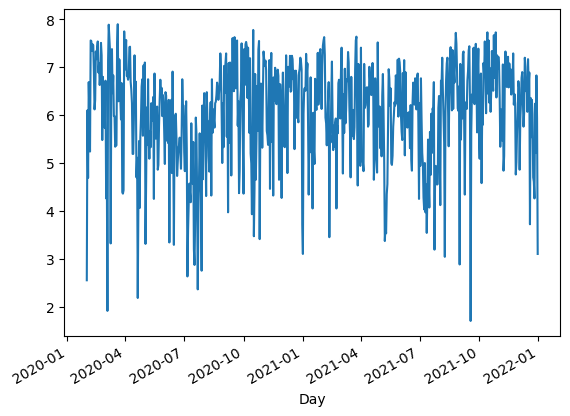

In [43]:
ghi_ground1.plot()

<Axes: xlabel='Day'>

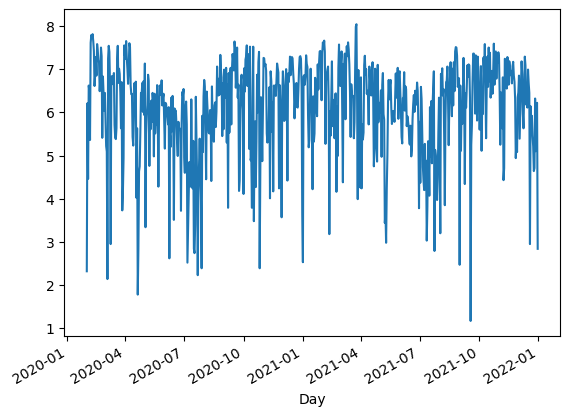

In [44]:
ghi_solargis.plot()

# Solcast

In [39]:
df_solcast1 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_solcast2020.csv')
df_solcast2 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_solcast2021.csv')

df_solcast = pd.concat([df_solcast1, df_solcast2], ignore_index=True)
df_solcast.dropna(axis=1, inplace=True)
df_solcast.drop(df_solcast.tail(1).index, inplace=True) #drop 2022 data
df_solcast.tail()

,air_temp,albedo,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,dhi,dni,ghi,gti,period_end,period
17538,26,0.14,0,0,0,0,0,0,0,0,2021-12-31T19:00:00Z,PT60M
17539,25,0.14,0,0,0,0,0,0,0,0,2021-12-31T20:00:00Z,PT60M
17540,24,0.14,0,0,0,0,0,0,0,0,2021-12-31T21:00:00Z,PT60M
17541,23,0.14,0,0,0,0,0,0,0,0,2021-12-31T22:00:00Z,PT60M
17542,23,0.14,0,0,0,0,0,0,0,0,2021-12-31T23:00:00Z,PT60M


In [40]:
df_solcast['Time'] = pd.to_datetime(df_solcast['period_end'])
df_solcast.set_index('Time', inplace=True)
df_solcast.sort_index(inplace=True)
df_solcast.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17543 entries, 2020-01-01 01:00:00+00:00 to 2021-12-31 23:00:00+00:00
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   air_temp      17543 non-null  int64  
 1   albedo        17543 non-null  float64
 2   clearsky_dhi  17543 non-null  int64  
 3   clearsky_dni  17543 non-null  int64  
 4   clearsky_ghi  17543 non-null  int64  
 5   clearsky_gti  17543 non-null  int64  
 6   dhi           17543 non-null  int64  
 7   dni           17543 non-null  int64  
 8   ghi           17543 non-null  int64  
 9   gti           17543 non-null  int64  
 10  period_end    17543 non-null  object 
 11  period        17543 non-null  object 
dtypes: float64(1), int64(9), object(2)
memory usage: 1.7+ MB


<Axes: xlabel='Time'>

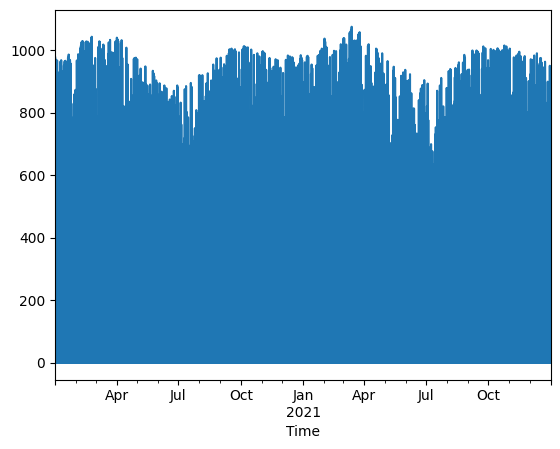

In [41]:
ghi_solcast = df_solcast['ghi']
ghi_solcast.plot()

<Axes: xlabel='Time'>

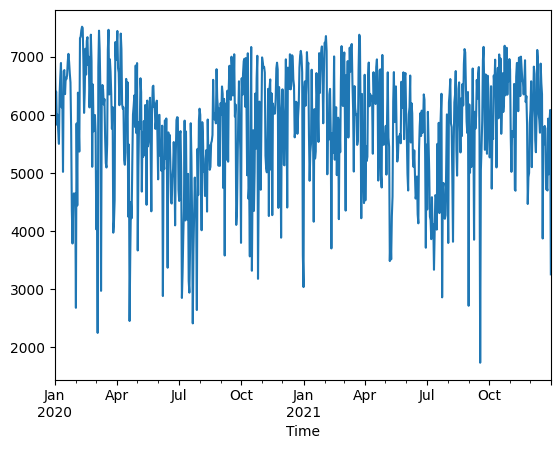

In [42]:
# resample to daily
ghi_solcast = ghi_solcast.resample('D').sum()
ghi_solcast.plot()

# CAMSRAD

In [18]:
df_camsrad1 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_CAMSRAD2020.csv')
df_camsrad2 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_CAMSRAD2021.csv')

df_camsrad = pd.concat([df_camsrad1, df_camsrad2], ignore_index=True)
df_camsrad.head()

,TAO (Wh/m2/day),Clear sky GHI (Wh/m2/day),Clear sky BHI (Wh/m2/day),Clear sky DHI (Wh/m2/day),Clear sky DNI (Wh/m2/day),GHI (Wh/m2/day),BHI (Wh/m2/day),DHI (Wh/m2/day),DNI (Wh/m2/day),Reliability,Time
0,9699.1562,7331.0845,6334.4102,996.6746,9667.6328,7331.0845,6334.4102,996.6746,9667.6328,0.9865,2020-01-01
1,9706.1738,7274.8804,6143.7466,1131.1338,9320.6133,7140.4941,5840.6284,1299.8656,8913.0938,0.9865,2020-01-02
2,9713.6855,7270.6318,6295.7139,974.9179,9631.1201,6998.1650,5363.7163,1634.4491,8324.0645,0.9865,2020-01-03
3,9721.7324,7184.0562,5942.0752,1241.9811,8932.4854,6153.7080,4306.4048,1847.3035,6437.6226,0.9861,2020-01-04
4,9730.1680,7244.6416,6240.5664,1004.0753,9501.7539,6680.6758,4899.8359,1780.8398,6718.1606,0.9865,2020-01-05


In [19]:
df_camsrad['Time'] = pd.to_datetime(df_camsrad['Time'])
df_camsrad.set_index('Time', inplace=True)
df_camsrad.sort_index(inplace=True)
df_camsrad.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2020-01-01 to 2021-12-31
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TAO (Wh/m2/day)            731 non-null    float64
 1   Clear sky GHI (Wh/m2/day)  731 non-null    float64
 2   Clear sky BHI (Wh/m2/day)  731 non-null    float64
 3   Clear sky DHI (Wh/m2/day)  731 non-null    float64
 4   Clear sky DNI (Wh/m2/day)  731 non-null    float64
 5   GHI (Wh/m2/day)            731 non-null    float64
 6   BHI (Wh/m2/day)            731 non-null    float64
 7   DHI (Wh/m2/day)            731 non-null    float64
 8   DNI (Wh/m2/day)            731 non-null    float64
 9   Reliability                731 non-null    float64
dtypes: float64(10)
memory usage: 62.8 KB


<Axes: xlabel='Time'>

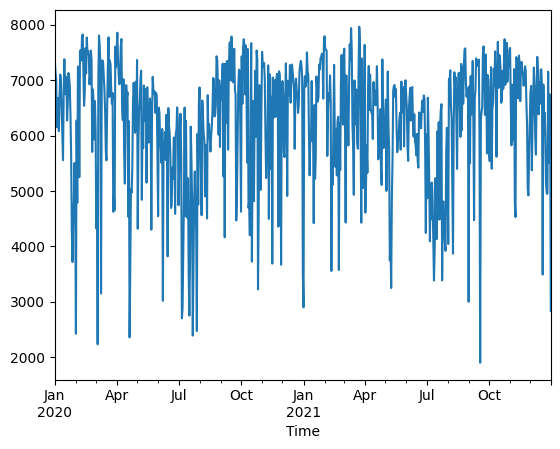

In [45]:
ghi_camsrad = df_camsrad['GHI (Wh/m2/day)']
ghi_camsrad.plot()

# NREL

In [46]:
df_nrel1 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_nrel2020.csv')
df_nrel2 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_nrel2021.csv')

df_nrel = pd.concat([df_nrel1, df_nrel2], ignore_index=True)
df_nrel.drop(columns=['index'], inplace=True)   
df_nrel.head()

,Date,Solar Zenith Angle (Degrees),Surface Albedo,Precipitable Water (cm),Clearsky DHI (W/m2),Clearsky DNI (W/m2),Clearsky GHI (W/m2),Cloud Type,Dew Point (C),Relative Humidity (%),Pressure (mbar),DHI (W/m2),DNI (W/m2),Fill Flag,GHI (W/m2),Temperature (C),Wind Direction (Degrees),Wind Speed (m/s)
0,2020-01-01 00:30:00,158.24,0.21,4.0,0,0,0,5,19.4,100.00,890,0,0,0,0,19.4,11,1.6
1,2020-01-01 01:30:00,156.49,0.21,4.0,0,0,0,4,19.2,100.00,890,0,0,0,0,19.2,14,1.4
2,2020-01-01 02:30:00,147.52,0.21,3.9,0,0,0,4,18.9,100.00,889,0,0,0,0,18.9,14,1.1
3,2020-01-01 03:30:00,135.43,0.20,2.5,0,0,0,0,15.1,78.81,890,0,0,0,0,18.9,71,2.2
4,2020-01-01 04:30:00,122.30,0.20,2.5,0,0,0,0,15.2,81.37,891,0,0,0,0,18.4,75,2.1


In [47]:
df_nrel['Date'] = pd.to_datetime(df_nrel['Date'])
df_nrel.set_index('Date', inplace=True)
df_nrel.sort_index(inplace=True)
df_nrel.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17520 entries, 2020-01-01 00:30:00 to 2021-12-31 23:30:00
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Solar Zenith Angle (Degrees)  17520 non-null  float64
 1   Surface Albedo                17520 non-null  float64
 2   Precipitable Water (cm)       17520 non-null  float64
 3   Clearsky DHI (W/m2)           17520 non-null  int64  
 4   Clearsky DNI (W/m2)           17520 non-null  int64  
 5   Clearsky GHI (W/m2)           17520 non-null  int64  
 6   Cloud Type                    17520 non-null  int64  
 7   Dew Point (C)                 17520 non-null  float64
 8   Relative Humidity (%)         17520 non-null  float64
 9   Pressure (mbar)               17520 non-null  int64  
 10  DHI (W/m2)                    17520 non-null  int64  
 11  DNI (W/m2)                    17520 non-null  int64  
 12  Fill Flag                

<Axes: xlabel='Date'>

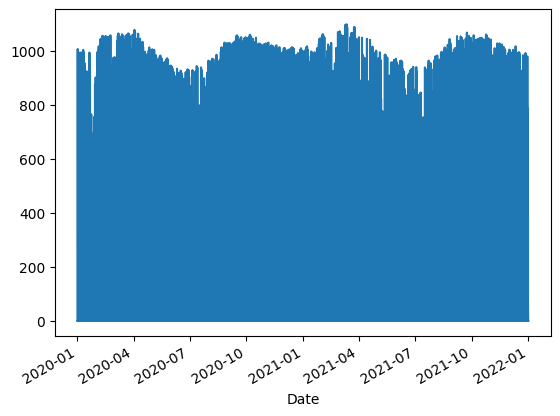

In [51]:
ghi_nrel = df_nrel['GHI (W/m2)']
ghi_nrel.plot()

<Axes: xlabel='Date'>

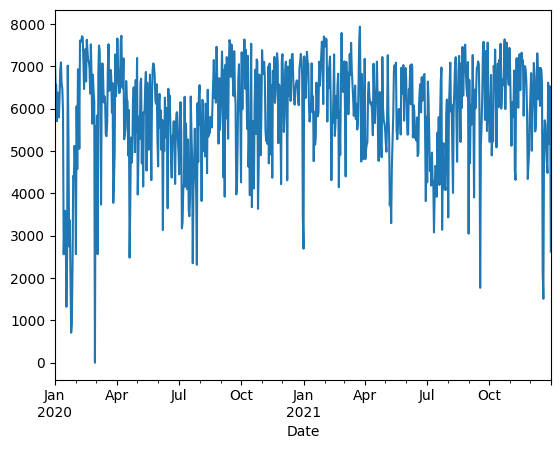

In [52]:
ghi_nrel = ghi_nrel.resample('D').sum()
ghi_nrel.plot() 